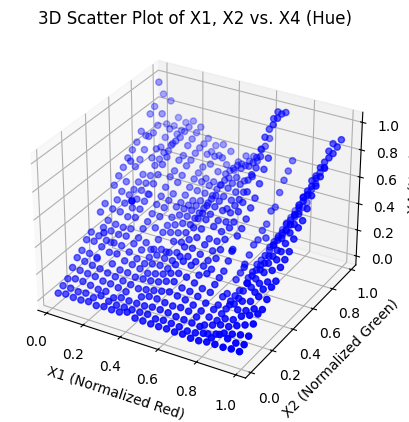

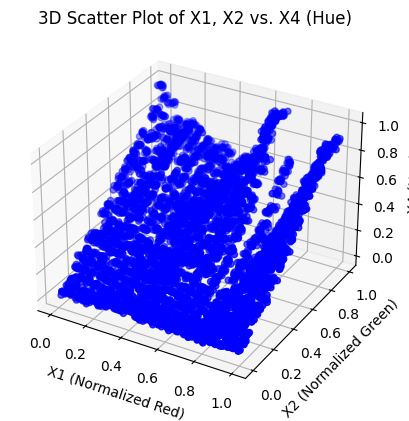

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from colorsys import rgb_to_hsv

# %% Data File Reader %%
# Read the CSV file, skipping the first row
data = pd.read_csv('SensorTuner/hsv_training.csv', header=0) 

# Extract columns 1 and 2 as Y (Python uses 0-based indexing)
Y = data.iloc[:, 1:3].values 

# Extract columns 3 to 6 as X
X_0 = data.iloc[:, 3:7].values

# Normalize RGB values to [0, 1]
X_norm = (X_0 - X_0.min(axis=0)) / (X_0.max(axis=0) - X_0.min(axis=0))

# Ensure values are within [0, 1] 
X_norm = np.clip(X_norm, 0, 1)

# Convert RGB to HSV (element-wise)
X_augment1 = np.apply_along_axis(lambda rgb: rgb_to_hsv(*rgb), 1, X_norm[:, :3])

# Concatenate everything
X = np.concatenate((X_norm, X_augment1[:, :2]), axis=1)

# %% Data Augmentation %%
X_augmented = X.copy()  # Initialize X_augmented with the original data
Y_augmented = Y.copy()  # Initialize Y_augmented with the original data

for j in range(10):  # Repeat 10 times
    # Generate normally distributed noise with std dev 0.01
    noise_X = 0.01 * np.random.randn(*X.shape) 
    noise_Y = 0.01 * np.random.randn(*Y.shape) 

    # Add noise to create augmented data
    X_plus = X + noise_X
    Y_plus = Y + noise_Y

    # Clip values to be between 0 and 1
    X_plus = np.clip(X_plus, 0, 1)
    Y_plus = np.clip(Y_plus, 0, 1)

    # Append augmented data 
    X_augmented = np.concatenate((X_augmented, X_plus), axis=0)
    Y_augmented = np.concatenate((Y_augmented, Y_plus), axis=0)



# %% 3D Scatter Plot %%
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y[:, 0], Y[:, 1], X[:, 5], c='b', marker='o')

ax.set_xlabel('X1 (Normalized Red)')
ax.set_ylabel('X2 (Normalized Green)')
ax.set_zlabel('X4 (Hue)')
ax.set_title('3D Scatter Plot of X1, X2 vs. X4 (Hue)')

plt.show()

# %% 3D Scatter Plot %%
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y_augmented[:, 0], Y_augmented[:, 1], X_augmented[:, 5], c='b', marker='o')

ax.set_xlabel('X1 (Normalized Red)')
ax.set_ylabel('X2 (Normalized Green)')
ax.set_zlabel('X4 (Hue)')
ax.set_title('3D Scatter Plot of X1, X2 vs. X4 (Hue)')

plt.show()


/Users/christopherwaight/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 0.1096 
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.0343
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - loss: 0.0130
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step - loss: 0.0079
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 0.0066
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - loss: 0.0060
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - loss: 0.0058
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 0.0057
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - loss: 0.0054
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 0.0051
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - loss: 0.0050
Epoch 12/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - loss: 0.0051
Epoch 13/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - loss: 0.0048
Epoch 14/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.0049
Epoch 15/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - l

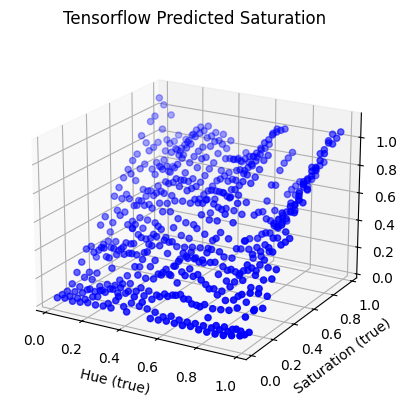

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

# Assuming X_augmented and Y_augmented are defined as in the previous code

# Extract the first column of Y_augmented as the target variable
y_train = Y_augmented[:, 1]

# Define the neural network model
model = keras.Sequential([
    layers.Input(shape=(6,)),  # Input layer with 6 dimensions
    layers.Dense(5, activation='relu'),  # Hidden layer with 4 neurons and ReLU activation
    layers.Dense(4, activation='relu'),  # Hidden layer with 3 neurons and ReLU activation
    layers.Dense(3, activation='relu'),  # Hidden layer with 2 neurons and ReLU activation
    layers.Dense(2, activation='relu'),  # Hidden layer with 2 neurons and ReLU activation
    layers.Dense(1)  # Output layer with 1 neuron (linear activation)
])

# Compile the model
model.compile(optimizer='adam', loss=tf.keras.losses.Huber(delta=10.0))

# Train the model
model.fit(X_augmented, y_train, epochs=20, batch_size=64, verbose=1)  # Adjust epochs and batch_size as needed

# Make predictions
y_pred = model.predict(X)

# %% 3D Scatter Plot with NN Predictions %%

# Create a grid of points for interpolation (using original Y for consistency)
X1grid, X2grid = np.meshgrid(np.linspace(Y[:, 0].min(), Y[:, 0].max(), 50),
                           np.linspace(Y[:, 1].min(), Y[:, 1].max(), 50))

# %% 3D Scatter Plot %%
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y[:, 0], Y[:, 1], y_pred, c='b', marker='o')

ax.set_xlabel('Hue (true)')
ax.set_ylabel('Saturation (true)')
ax.set_zlabel('Sat (Predicted)')
ax.set_title('Tensorflow Predicted Saturation')

# Adjust the view angle to prevent overlap
ax.view_init(elev=20, azim=-60)  # You might need to tweak these values

# Add padding to the z-axis label
ax.zaxis.labelpad = 15  # Adjust the value as needed

plt.show()